In [30]:
import pandas as pd
import numpy  as np


In [31]:
from sklearn.datasets import load_diabetes

In [32]:
data= load_diabetes()
x=data.data 
y=data.target

In [33]:
df=pd.DataFrame(x,columns=data.feature_names)

In [34]:
df["target"]=y

In [35]:
print(df.shape)
print(df.head())

(442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [36]:
print("Data cleaning")

Data cleaning


In [37]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [38]:
duplicated_count =df.duplicated().sum()
print(f"\nduplicated row:{duplicated_count}")


duplicated row:0


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_clean=df.drop("target",axis=1)
y_clean=df["target"]

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x_clean,y_clean,test_size=0.2,random_state=42)

In [42]:
print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")

Training samples: 353
Testing samples: 89


In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
for feature, coef in zip(data.feature_names, model.coef_):
    print(f"  {feature:10s} -> weight = {coef:.2f}")
print(f"Bias (intercept) = {model.intercept_:.2f}")


  age        -> weight = 37.90
  sex        -> weight = -241.96
  bmi        -> weight = 542.43
  bp         -> weight = 347.70
  s1         -> weight = -931.49
  s2         -> weight = 518.06
  s3         -> weight = 163.42
  s4         -> weight = 275.32
  s5         -> weight = 736.20
  s6         -> weight = 48.67
Bias (intercept) = 151.35


In [46]:
y_predict=model.predict(x_test)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [51]:
mse=mean_squared_error(y_test,y_predict)
rmse=np.sqrt(mse)
mae=mean_squared_error(y_test,y_predict)
r2 = r2_score(y_test, y_predict)

In [52]:
print(f"MSE  (Mean Squared Error)  : {mse:.2f}")


MSE  (Mean Squared Error)  : 2900.19


In [53]:
print(f"RMSE (Root MSE)            : {rmse:.2f}")

RMSE (Root MSE)            : 53.85


In [54]:
print(f"MAE  (Mean Absolute Error) : {mae:.2f}")

MAE  (Mean Absolute Error) : 2900.19


In [55]:
print(f"R² Score                   : {r2:.3f}")

R² Score                   : 0.453


In [56]:
print("SAMPLE PREDICTION VS ACTUAL")

SAMPLE PREDICTION VS ACTUAL


In [58]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": np.round(y_predict[:10], 1)
})
print(comparison.to_string(index=False))

 Actual  Predicted
  219.0      139.5
   70.0      179.5
  202.0      134.0
  230.0      291.4
  111.0      123.8
   84.0       92.2
  242.0      258.2
  272.0      181.3
   94.0       90.2
   96.0      108.6


In [59]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Actual vs Predicted Values')

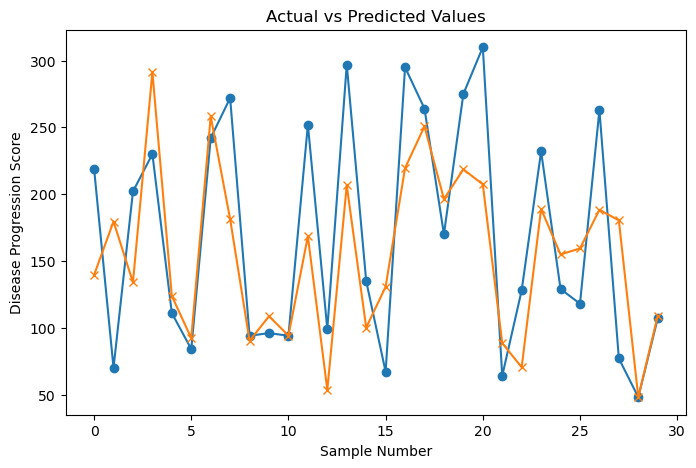

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:30], label="Actual", marker="o")
plt.plot(y_predict[:30], label="Predicted", marker="x")
plt.xlabel("Sample Number")
plt.ylabel("Disease Progression Score")
plt.title("Actual vs Predicted Values")